# Notebook 3 — Exploratory Data Analysis

This notebook helps to produce the six figures that make the blog post.

## The three lenses that I will evidence with the data

1. **Wealth concentration** — Gini coefficient of squad market values across 10 leagues, 2006–2025. Is Serie A 'uniquely unequal'?
2. **Foreigners in Serie A** — share of non-Italian players over time vs other top-10 leagues. Has the door opened faster and wider in Italy?
3. **Italy's results** — tournament performance score 1982–2026, with the 2018/2022 WC failures in context.

## Known data limitation

Tournament-squad club data is missing for 2006–2024 (Transfermarkt kader pages change the `club` selector). We have player names and market values for those years, plus full club info for the 2018 and 2022 qualifier squads (the failure years). The "talent drain" analysis is therefore a **focused case study on the failure years**, not a full time series.

## Figures produced

| # | File | What it shows |
|---|------|---------------|
| 1 | `fig1_gini_leagues.png`       | Gini coefficient by league, 2006–2025 (Italy highlighted) |
| 2 | `fig2_foreign_pct.png`        | % foreign players in each league over time |
| 3 | `fig3_italy_results.png`      | Italy's tournament performance score timeline |
| 4 | `fig4_squad_depth.png`        | Distribution of player market values within each Italy squad, coloured by result |
| 5 | `fig5_scatter_gini_value.png` | Gini × total league market value (2025) — cost of concentration |
| 6 | `fig6_italy_squad_value.png`  | Italy's squad value at each tournament 2006–2024 |


## 0. Setup

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CLEAN_DIR = Path('../data/clean')
OUT_DIR   = Path('../output/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

league_season     = pd.read_csv(CLEAN_DIR / 'league_season.csv')
italy_squad_clean = pd.read_csv(CLEAN_DIR / 'italy_squad_clean.csv')
italy_final       = pd.read_csv(CLEAN_DIR / 'italy_final.csv')

# Raw italy results (1982–2026) are used in figures 2 and 3, but not in the main analysis, which relies on the cleaned italy_final table
italy_results     = pd.read_csv('../data/raw/italy_results.csv')

# Presentation settings
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'font.family': 'DejaVu Sans', 'font.size': 11,
})

AZZURRI = '#0066B2'  # Italy national-team blue
GREY    = '#888888'
RED     = '#C8102E'

# Consistent league ordering
LEAGUES = ['England', 'Spain', 'Germany', 'Italy', 'France',
           'Portugal', 'Netherlands', 'Belgium', 'Turkey', 'Czechia']

print(f'league_season:     {len(league_season)} rows, {league_season.country.nunique()} leagues, '
      f'{league_season.season_start.min()}–{league_season.season_start.max()}')
print(f'italy_squad_clean: {len(italy_squad_clean)} rows across {italy_squad_clean.year.nunique()} tournaments')
print(f'italy_final:       {len(italy_final)} rows')
print(f'italy_results:     {len(italy_results)} tournaments, {italy_results.year.min()}–{italy_results.year.max()}')

league_season:     200 rows, 10 leagues, 2006–2025
italy_squad_clean: 413 rows across 10 tournaments
italy_final:       11 rows
italy_results:     13 tournaments, 2000–2026


---
## Figure 1 — Gini coefficient of squad market values, 2006–2025

Italy is highlighted in the classical Azzurri blue. A higher Gini means wealth is more concentrated in a handful of clubs, indicating inequality. If the "Serie A decline is caused by wealth concentration" hypothesis holds, Italy should sit at or above the top league average.

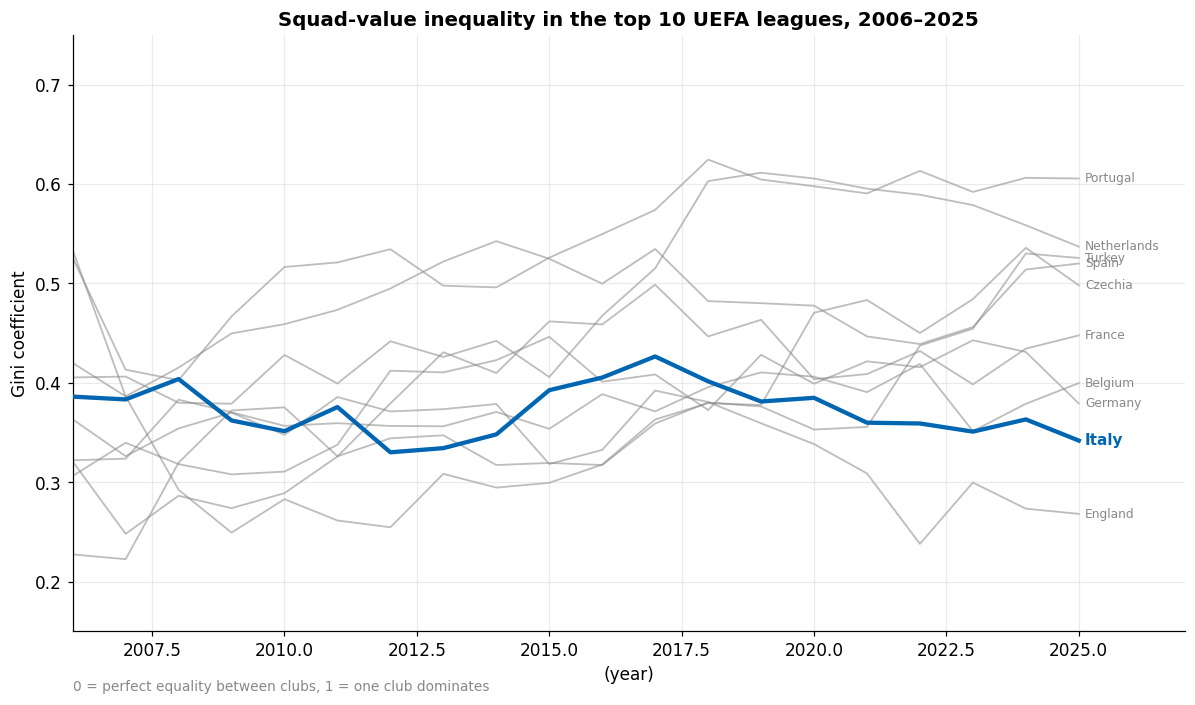

Italy 2025 Gini: 0.342
Rank among 10 leagues: 9 of 10


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))

for country in LEAGUES:
    d = league_season[league_season.country == country].sort_values('season_start')
    is_italy = country == 'Italy'
    ax.plot(d.season_start, d.gini_coefficient,
            color=AZZURRI if is_italy else GREY,
            lw=2.8 if is_italy else 1.2,
            alpha=1.0 if is_italy else 0.55,
            label=country if is_italy else None,
            zorder=3 if is_italy else 1)
    # Label the non-Italy leagues at the right end
    if not is_italy and len(d):
        last = d.iloc[-1]
        ax.annotate(country, (last.season_start, last.gini_coefficient),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=8, color=GREY, va='center')

# Label Italy at right
italy_last = league_season[league_season.country=='Italy'].sort_values('season_start').iloc[-1]
ax.annotate('Italy', (italy_last.season_start, italy_last.gini_coefficient),
            xytext=(4, 0), textcoords='offset points',
            fontsize=10, color=AZZURRI, fontweight='bold', va='center')

ax.set_xlabel('(year)')
ax.set_ylabel('Gini coefficient')
ax.set_title('Squad-value inequality in the top 10 UEFA leagues, 2006–2025',
             fontsize=13, fontweight='bold', loc='center' )
ax.text(0, -0.1, '0 = perfect equality between clubs, 1 = one club dominates',
        transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlim(2006, 2027)
ax.set_ylim(0.15, 0.75)

fig.tight_layout()
fig.savefig(OUT_DIR / 'fig1_gini_leagues.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Italy 2025 Gini: {italy_last.gini_coefficient:.3f}')
print(f'Rank among 10 leagues:', (league_season[league_season.season_start==2025]
      .sort_values('gini_coefficient', ascending=False).country.tolist().index('Italy') + 1), 'of 10')

---
## Figure 2 — % foreign players by league, 2006–2025

Tracks the share of non-nationals in each top-flight league. If Italy's post-Bosman open door is choking off Italian talent, it is expected that Italy's line will rise faster than peer leagues.

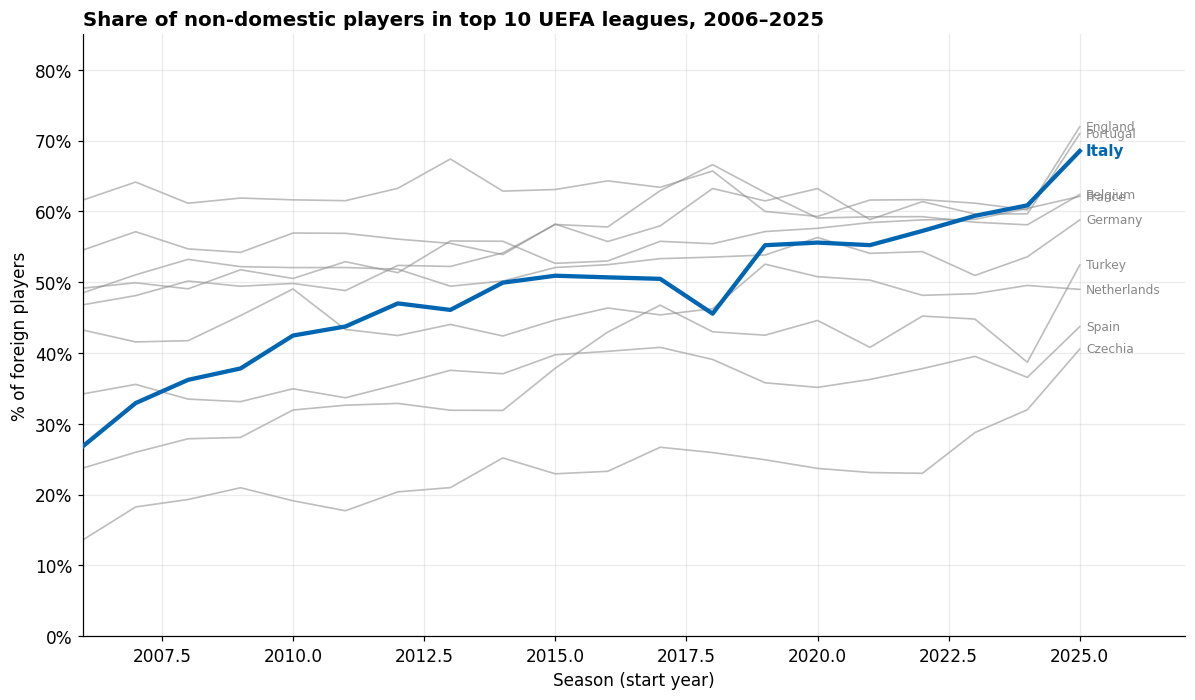

Italy 2006 % foreign: 26.9%
Italy 2025 % foreign: 68.5%
Change: +41.7 pp
Italy 2025 rank: 3 of 10
Average change across all leagues: +17.8 pp


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))

for country in LEAGUES:
    d = league_season[league_season.country == country].sort_values('season_start')
    is_italy = country == 'Italy'
    ax.plot(d.season_start, d.pct_foreign,
            color=AZZURRI if is_italy else GREY,
            lw=2.8 if is_italy else 1.1,
            alpha=1.0 if is_italy else 0.55,
            zorder=3 if is_italy else 1)
    if len(d):
        last = d.iloc[-1]
        ax.annotate(country, (last.season_start, last.pct_foreign),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=8 if not is_italy else 10,
                    color=AZZURRI if is_italy else GREY,
                    fontweight='bold' if is_italy else 'normal',
                    va='center')

ax.set_xlabel('Season (start year)')
ax.set_ylabel('% of foreign players')
ax.set_title('Share of non-domestic players in top 10 UEFA leagues, 2006–2025',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(2006, 2027)
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

fig.tight_layout()
fig.savefig(OUT_DIR / 'fig2_foreign_pct.png', bbox_inches='tight', dpi=150)
plt.show()

# Highlight Italy's trajectory numerically
italy_trend = league_season[league_season.country=='Italy'].sort_values('season_start')
print(f'Italy 2006 % foreign: {italy_trend.iloc[0].pct_foreign:.1f}%')
print(f'Italy 2025 % foreign: {italy_trend.iloc[-1].pct_foreign:.1f}%')
print(f'Change: +{italy_trend.iloc[-1].pct_foreign - italy_trend.iloc[0].pct_foreign:.1f} pp')
print(f'Italy 2025 rank: {league_season[league_season.season_start==2025].sort_values("pct_foreign", ascending=False).country.tolist().index("Italy") + 1} of 10')
# Italy's change compared to the average change across all leagues
avg_change = league_season.groupby('country').apply(lambda g: g.sort_values('season_start').iloc[-1].pct_foreign - g.sort_values('season_start').iloc[0].pct_foreign).mean()
print(f'Average change across all leagues: +{avg_change:.1f} pp')


---
## Figure 3 — Italy's tournament performance, 1982–2026

This is a simple timeline of Italy's World Cup + Euro results, scored 1–7. The two DNQs (2018 WC, 2022 WC) stand out as the worst results since the 1958 WC. Note the 2020 Euro is offset as the tournament happened in 2021 because of Covid restrictions.

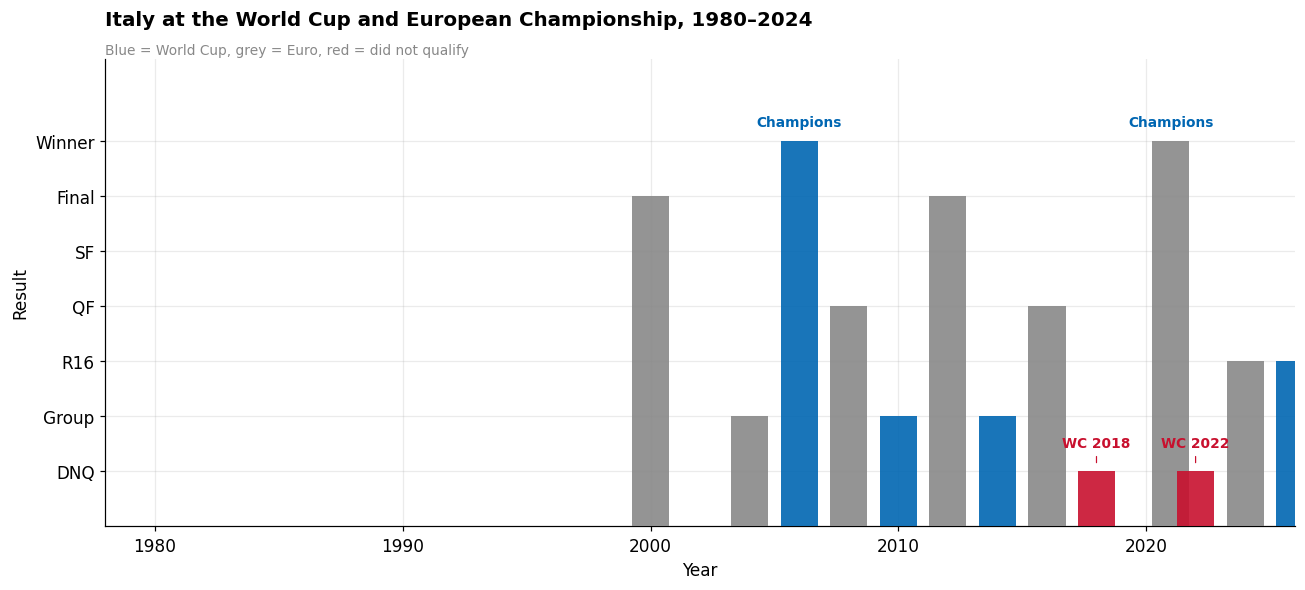

 year tournament          result  performance_score
 2000       Euro       Runner-up                  6
 2004       Euro     Group Stage                  2
 2006  World Cup          Winner                  7
 2008       Euro   Quarter-final                  4
 2010  World Cup     Group Stage                  2
 2012       Euro       Runner-up                  6
 2014  World Cup     Group Stage                  2
 2016       Euro   Quarter-final                  4
 2018  World Cup Did Not Qualify                  1
 2021       Euro          Winner                  7
 2022  World Cup Did Not Qualify                  1
 2024       Euro     Round of 16                  3
 2026  World Cup       Qualified                  3


In [ ]:
res = italy_results.copy().sort_values('year').reset_index(drop=True)

# Colour-code by tournament
colors = np.where(res.tournament == 'World Cup', AZZURRI, GREY)
# Red for DNQ (qualifier rows)
colors = np.where(res.performance_score == 1, RED, colors)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(res.year, res.performance_score, color=colors, width=1.5, alpha=0.9, zorder=3)

# Performance labels on y-axis
ax.set_yticks([1, 2, 3, 4, 5, 6, 7])
ax.set_yticklabels(['DNQ', 'Group', 'R16', 'QF', 'SF', 'Final', 'Winner'])
ax.set_xlabel('Year')
ax.set_ylabel('Result')
ax.set_title("Italy at the World Cup and European Championship, 1980–2024",
             fontsize=13, fontweight='bold', loc='left', pad=22)
ax.text(0, 1.01, 'Blue = World Cup, grey = Euro, red = did not qualify',
        transform=ax.transAxes, fontsize=9, color=GREY)

# Annotate every DNQ with its tournament code
for _, r in res[res.performance_score == 1].iterrows():
    code_ = 'WC' if r.tournament == 'World Cup' else 'Euro'
    ax.annotate(f'{code_} {int(r.year)}', (r.year, 1.1),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, color=RED, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=RED, lw=0.8))

# Annotate the 2006 win
win = res[res.result == 'Winner']
for _, r in win.iterrows():
    ax.annotate('Champions', (r.year, 7),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=AZZURRI, fontweight='bold')

ax.set_xlim(1978, 2026)
ax.set_ylim(0, 8.5)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig3_italy_results.png', bbox_inches='tight', dpi=150)
plt.show()
print(res[['year','tournament','result','performance_score']].to_string(index=False))

---
## Figure 4 — Squad depth: distribution of player values within each Italy squad

It is important to understand two squads can have the same *total* market value but look very different inside: one might have a few extremely valuable players and a majority of lower-valued players, the other twenty just solidily valued players. This figure plots every valued player as a dot, grouped by tournament, with the colour of the row showing the result Italy achieved. Gives an immediate visual sense of squad depth year-to-year.

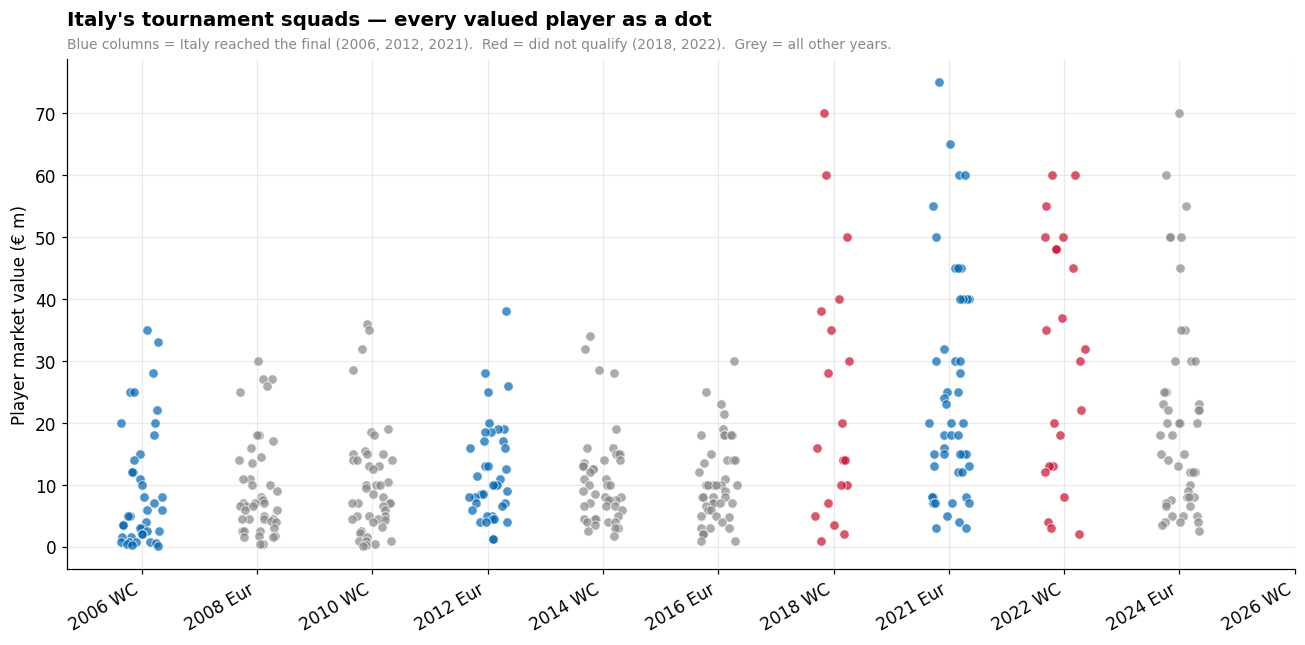

Per-tournament squad summary (players with market values only):
       n       mean   top3    total    variance
year                                           
2006  42   9.032143   96.0   379.35   93.798393
2008  45   9.368889   84.0   421.60   61.687646
2010  47  10.226596  103.0   480.65   77.294549
2012  39  12.074359   92.0   470.90   64.692483
2014  47  10.804255   94.5   507.80   56.170416
2016  47  10.325532   78.0   485.30   46.169769
2018  19  23.868421  180.0   453.50  414.884503
2021  49  25.081633  200.0  1229.00  327.368197
2022  22  30.227273  175.0   665.00  383.707792
2024  49  20.704082  185.0  1014.50  274.061650


In [ ]:
# One dot per player per tournament, value on y-axis
s = italy_squad_clean.dropna(subset=['market_value_m']).copy()

# Attach tournament result so we can colour each column
res_lookup = italy_final.set_index('year')[['result','performance_score','tournament']]
s = s.merge(res_lookup[['result','performance_score']],
            left_on='year', right_index=True, how='left')

# Column order by year; build a label 'YYYY Euro/WC'
label_df = (italy_final[['year','tournament','result','performance_score']]
            .drop_duplicates('year').sort_values('year'))
label_df['label'] = (label_df.year.astype(str) + ' ' +
                     label_df.tournament.str[:3].replace({'Wor':'WC'}))
label_df = label_df.reset_index(drop=True)
label_to_xpos = {r.label: i for i, r in label_df.iterrows()}

# Colour by performance score: red for DNQ, grey for middling, blue for F+/winner
def _colour(score):
    if pd.isna(score): return GREY
    if score == 1:     return RED
    if score >= 6:     return AZZURRI
    return GREY

fig, ax = plt.subplots(figsize=(12, 6))
rng = np.random.default_rng(7)
for _, row in label_df.iterrows():
    sub = s[s.year == row.year]
    if len(sub) == 0:
        continue
    xc = label_to_xpos[row.label]
    jitter = rng.uniform(-0.18, 0.18, size=len(sub))
    ax.scatter(xc + jitter, sub.market_value_m,
               color=_colour(row.performance_score),
               alpha=0.70, s=38, edgecolor='white', lw=0.6, zorder=3)

ax.set_xticks(list(label_to_xpos.values()))
ax.set_xticklabels(list(label_to_xpos.keys()), rotation=30, ha='right')
ax.set_ylabel('Player market value (€ m)')
ax.set_title("Italy's tournament squads — every valued player as a dot",
             fontsize=13, fontweight='bold', loc='left', pad=22)
ax.text(0, 1.02,
        'Blue columns = Italy reached the final (2006, 2012, 2021).  '
        'Red = did not qualify (2018, 2022).  Grey = all other years.',
        transform=ax.transAxes, fontsize=9, color=GREY)

fig.tight_layout()
fig.savefig(OUT_DIR / 'fig4_squad_depth.png', bbox_inches='tight', dpi=150)
plt.show()

summary = (s.groupby('year')
             .agg(n=('player','count'),
                  mean=('market_value_m','mean'),
                  top3=('market_value_m', lambda x: x.nlargest(3).sum()),
                  total=('market_value_m','sum'),
                  variance=('market_value_m','var')))
print('Per-tournament squad summary (players with market values only):')
print(summary.to_string())



---
## Figure 5 — Concentration vs size

Does a bigger league also mean a more concentrated one? Scatter plot: total league market value (2025) vs Gini coefficient. If Italy is an outlier: large league, yet the money is spread thinly, that's a distinct competitive-balance story.

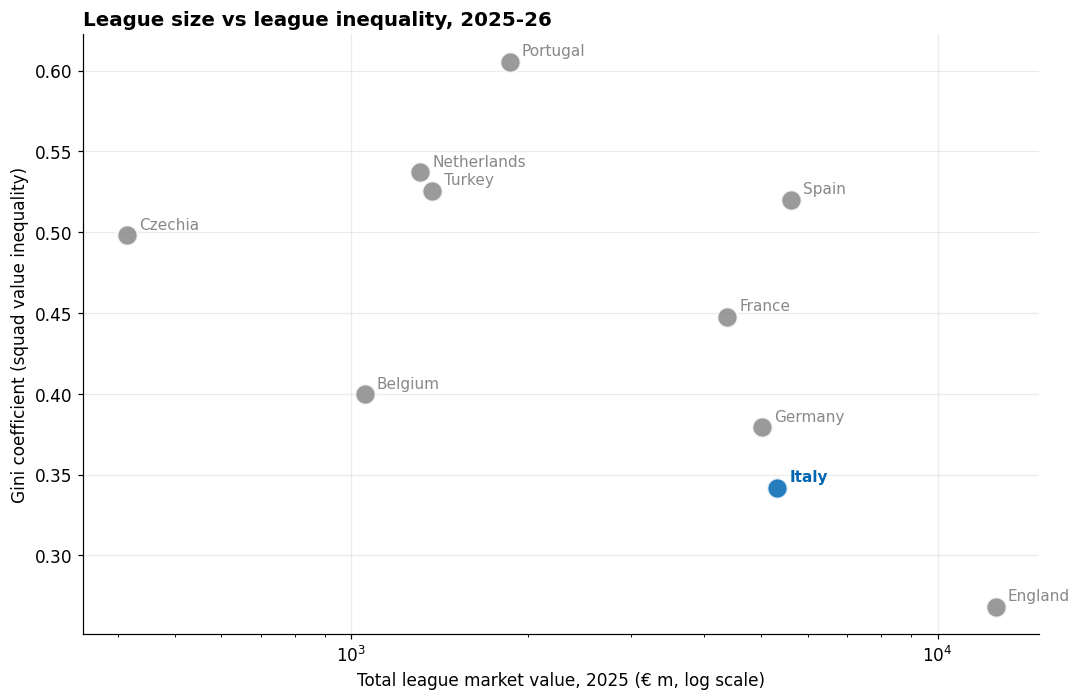

    country  total_market_value_m  gini_coefficient  pct_foreign
    England              12564.28            0.2682        71.97
      Spain               5624.10            0.5200        43.74
      Italy               5331.91            0.3419        68.54
    Germany               5016.33            0.3792        58.80
     France               4376.25            0.4477        62.13
   Portugal               1862.53            0.6055        70.99
     Turkey               1372.33            0.5256        52.44
Netherlands               1311.18            0.5370        48.99
    Belgium               1054.05            0.3997        62.39
    Czechia                414.03            0.4981        40.56


In [ ]:
latest = league_season[league_season.season_start == league_season.season_start.max()].copy()

fig, ax = plt.subplots(figsize=(10, 6.5))
for _, r in latest.iterrows():
    c = AZZURRI if r.country=='Italy' else GREY
    ax.scatter(r.total_market_value_m, r.gini_coefficient,
               s=180, color=c, alpha=0.85, edgecolor='white', lw=1.5, zorder=3)
    ax.annotate(r.country, (r.total_market_value_m, r.gini_coefficient),
                xytext=(8, 4), textcoords='offset points',
                fontsize=10, color=c,
                fontweight='bold' if r.country=='Italy' else 'normal')

ax.set_xscale('log')
ax.set_xlabel('Total league market value, 2025 (€ m, log scale)')
ax.set_ylabel('Gini coefficient (squad value inequality)')
ax.set_title('League size vs league inequality, 2025-26',
             fontsize=13, fontweight='bold', loc='left')


fig.tight_layout()
fig.savefig(OUT_DIR / 'fig5_scatter_gini_value.png', bbox_inches='tight', dpi=150)
plt.show()
print(latest[['country','total_market_value_m','gini_coefficient','pct_foreign']]
      .sort_values('total_market_value_m', ascending=False).to_string(index=False))

---
## Figure 6 — Italy's national-team squad value, 2006–2024

Are the Azzurri getting less valuable? Each bar is one tournament, the 2006 winners and 2021 Euro winners are the two peaks to watch. Qualifier squads (2018/22 WC failures) are also important.

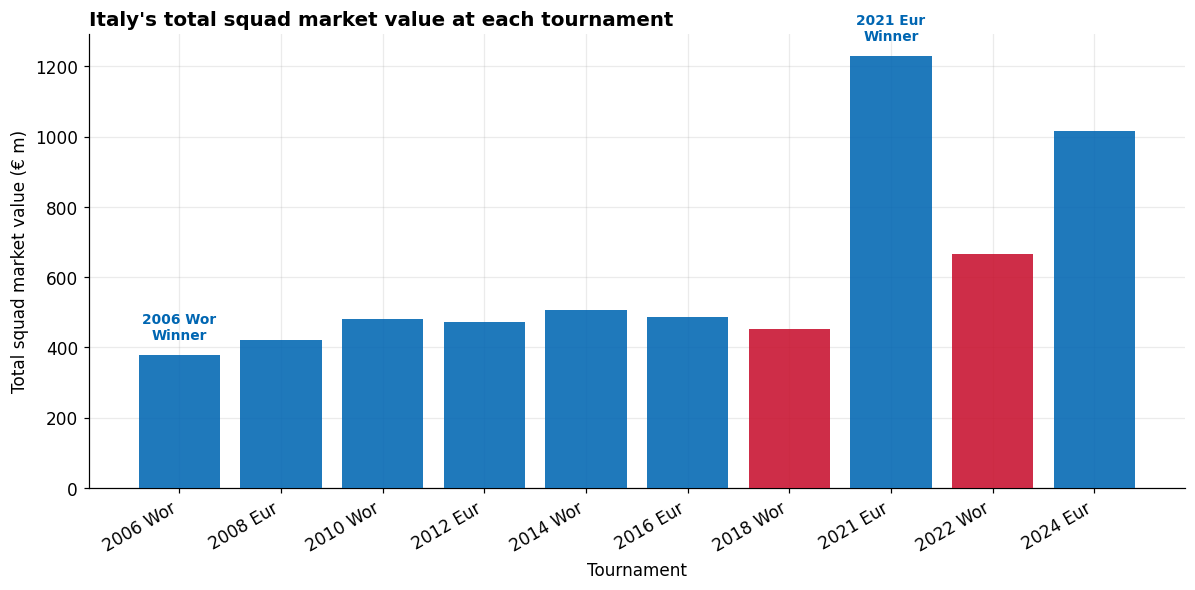

 year tournament          result  total_value_m  avg_value_m  top_value_m
 2006  World Cup          Winner         379.35         9.03         35.0
 2008       Euro   Quarter-final         421.60         9.37         30.0
 2010  World Cup     Group Stage         480.65        10.23         36.0
 2012       Euro       Runner-up         470.90        12.07         38.0
 2014  World Cup     Group Stage         507.80        10.80         34.0
 2016       Euro   Quarter-final         485.30        10.33         30.0
 2018  World Cup Did Not Qualify         453.50        23.87         70.0
 2021       Euro          Winner        1229.00        25.08         75.0
 2022  World Cup Did Not Qualify         665.00        30.23         60.0
 2024       Euro     Round of 16        1014.50        20.70         70.0


In [ ]:
f = italy_final.dropna(subset=['total_value_m']).sort_values('year').copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = np.where(f.qualified == 0, RED, AZZURRI)
ax.bar(f.year.astype(str) + ' ' + f.tournament.str[:3], f.total_value_m,
       color=colors, alpha=0.88, zorder=3)
ax.set_ylabel('Total squad market value (€ m)')
ax.set_xlabel('Tournament')
ax.set_title("Italy's total squad market value at each tournament",
             fontsize=13, fontweight='bold', loc='left')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Annotate 2006 winners + 2021 Euro winners
for _, r in f[f.result.isin(['Winner'])].iterrows():
    label = f'{int(r.year)} {r.tournament[:3]}\n{r.result}'
    ax.annotate(label, (f'{int(r.year)} {r.tournament[:3]}', r.total_value_m),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=AZZURRI, fontweight='bold')

fig.tight_layout()
fig.savefig(OUT_DIR / 'fig6_italy_squad_value.png', bbox_inches='tight', dpi=150)
plt.show()
print(f[['year','tournament','result','total_value_m','avg_value_m','top_value_m']].to_string(index=False))

---
## All figures saved

All six figures are written to `output/figures/`. Now I can run the regression analysis that backs up the descriptive picture shown here.

In [ ]:
figs = sorted(Path(OUT_DIR).glob('*.png'))
for f in figs:
    print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')
print(f'\n{len(figs)} figures produced, move on to 04_modeling.ipynb.')

  fig1_gini_leagues.png  (203 KB)
  fig2_foreign_pct.png  (169 KB)
  fig3_italy_results.png  (52 KB)
  fig4_squad_depth.png  (136 KB)
  fig5_scatter_gini_value.png  (74 KB)
  fig6_italy_squad_value.png  (59 KB)

6 figures produced, move on to 04_modeling.ipynb.
